# Определение токсичных комментариев 

**Описание проекта:**

Интернет-магазин запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 


**Цель исследования:**

Обучить модель классифицировать комментарии на позитивные и негативные. В распоряжении - набор данных с разметкой о токсичности правок.

**Критерии, которые важны заказчику:**
* Значение метрики качества `f1` не меньше 0.75.

**Ход исследования:**

* загрузка данных;
* предобработка данных;
* исследовательский анализ данных;
* обучение моделей, получение предсказаний;
* итоговые выводы


**Признаковое описание данных:**

* `text` - текст комментария

**Целевой признак:**
 
* `toxic` — метка класса: 0 - позитивные комментарии, 1 - негативные

**Файлы с данными:**

* /datasets/toxic_comments.csv


## Загрузка данных

In [1]:
#импортируем необходимые библиотеки

import os

import pandas as pd
import numpy as np

import re

from wordcloud import WordCloud

import nltk

nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')

from nltk.tokenize import wordpunct_tokenize

from nltk.corpus import stopwords

from tqdm.notebook import tqdm

import spacy

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import (CountVectorizer,
                                             TfidfVectorizer)

from sklearn.linear_model import LogisticRegression

import gensim.downloader as gensim_api

import torch
import transformers as ppb

import optuna
from optuna import distributions

from sklearn.metrics import (f1_score,
                             confusion_matrix)

import time

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
#настроим отображение графиков и ширину столбцов
plt.rcParams['figure.figsize'] = (15, 10)
pd.set_option('display.max_colwidth', 500)

In [3]:
#считываем файлы
pth1_1 = '/datasets/toxic_comments.csv'
pth1_2 = 'toxic_comments.csv'


if os.path.exists(pth1_1):
    toxic = pd.read_csv(pth1_1)
elif os.path.exists(pth1_2):
    toxic = pd.read_csv(pth1_2)
else:
    print('Something is wrong with file toxic_comments.csv')

In [4]:
#посмотрим на данные в файле toxic
toxic.head(10)

,Unnamed: 0,text,toxic
0,0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0
1,1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0
2,2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0
3,3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess t...",0
4,4,"You, sir, are my hero. Any chance you remember what page that's on?",0
5,5,"""\n\nCongratulations from me as well, use the tools well. · talk """,0
6,6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1
7,7,"Your vandalism to the Matt Shirvington article has been reverted. Please don't do it again, or you will be banned.",0
8,8,"Sorry if the word 'nonsense' was offensive to you. Anyway, I'm not intending to write anything in the article(wow they would jump on me for vandalism), I'm merely requesting that it be more encyclopedic so one can use it for school as a reference. I have been to the selective breeding page but it's almost a stub. It points to 'animal breeding' which is a short messy article that gives you no info. There must be someone around with expertise in eugenics? 93.161.107.169",0
9,9,alignment on this subject and which are contrary to those of DuLithgow,0


Помимо собственно комментариев `text` и таргета `toxic` есть неочевидный признак `Unnamed: 0`. Посмотрим далее, что из себя представляют значения в нём

Таким образом, в данном разделе импортировали необходимые библиотеки, настроили отображение данных, загрузили датасет

## Предобработка данных

In [5]:
#функция, возвращающая базовую информацию о датафрейме
def df_basic_info(df):
    #df - датафрейм
    
    print(f'Названия столбцов\n\n{df.columns}')
    print('----------------------------------------------------------------')
    print('Основные параметры данных\n\n')
    df.info()
    print('----------------------------------------------------------------')
    print(f'Число уникальных значений признаков\n\n{df.nunique()}')
    print('----------------------------------------------------------------')
    print(f'Типы данных\n\n{df.dtypes.value_counts()}')
    print('----------------------------------------------------------------')
    print(f'Размер датафрейма\n\n{df.shape}')
    print('----------------------------------------------------------------')
    print(f'Базовые статистики\n\n{df.describe()}')
    print('----------------------------------------------------------------')
    print(f'Доля пропущенных значений\n\n{df.isna().mean().sort_values()}')
    print('----------------------------------------------------------------')
    print(f'Количество полных дубликатов\n\n{df.duplicated().sum()}')
    print('----------------------------------------------------------------')
    return df.head(10)

Посмотрим на базовую информацию о данных

In [6]:
df_basic_info(toxic)

Названия столбцов

Index(['Unnamed: 0', 'text', 'toxic'], dtype='object')
----------------------------------------------------------------
Основные параметры данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  159292 non-null  int64 
 1   text        159292 non-null  object
 2   toxic       159292 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.6+ MB
----------------------------------------------------------------
Число уникальных значений признаков

Unnamed: 0    159292
text          159292
toxic              2
dtype: int64
----------------------------------------------------------------
Типы данных

int64     2
object    1
dtype: int64
----------------------------------------------------------------
Размер датафрейма

(159292, 3)
----------------------------------------------------------------
Базовые статис

,Unnamed: 0,text,toxic
0,0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0
1,1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0
2,2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0
3,3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess t...",0
4,4,"You, sir, are my hero. Any chance you remember what page that's on?",0
5,5,"""\n\nCongratulations from me as well, use the tools well. · talk """,0
6,6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1
7,7,"Your vandalism to the Matt Shirvington article has been reverted. Please don't do it again, or you will be banned.",0
8,8,"Sorry if the word 'nonsense' was offensive to you. Anyway, I'm not intending to write anything in the article(wow they would jump on me for vandalism), I'm merely requesting that it be more encyclopedic so one can use it for school as a reference. I have been to the selective breeding page but it's almost a stub. It points to 'animal breeding' which is a short messy article that gives you no info. There must be someone around with expertise in eugenics? 93.161.107.169",0
9,9,alignment on this subject and which are contrary to those of DuLithgow,0


Имеем практически 160000 размеченных записей с комментариями. Судя по количеству уникальных значений признака `Unnamed: 0`, он не несёт какой-либо смысловой нагрузки. Удалим данный признак и ещё раз посмотрим на обновлённые данные

In [7]:
toxic.drop(['Unnamed: 0'], axis=1, inplace=True)
df_basic_info(toxic)

Названия столбцов

Index(['text', 'toxic'], dtype='object')
----------------------------------------------------------------
Основные параметры данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ MB
----------------------------------------------------------------
Число уникальных значений признаков

text     159292
toxic         2
dtype: int64
----------------------------------------------------------------
Типы данных

int64     1
object    1
dtype: int64
----------------------------------------------------------------
Размер датафрейма

(159292, 2)
----------------------------------------------------------------
Базовые статистики

               toxic
count  159292.000000
mean        0.101612
std         0.302139
min         

,text,toxic
0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0
1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0
2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0
3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess t...",0
4,"You, sir, are my hero. Any chance you remember what page that's on?",0
5,"""\n\nCongratulations from me as well, use the tools well. · talk """,0
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1
7,"Your vandalism to the Matt Shirvington article has been reverted. Please don't do it again, or you will be banned.",0
8,"Sorry if the word 'nonsense' was offensive to you. Anyway, I'm not intending to write anything in the article(wow they would jump on me for vandalism), I'm merely requesting that it be more encyclopedic so one can use it for school as a reference. I have been to the selective breeding page but it's almost a stub. It points to 'animal breeding' which is a short messy article that gives you no info. There must be someone around with expertise in eugenics? 93.161.107.169",0
9,alignment on this subject and which are contrary to those of DuLithgow,0


Отметим, что в данных отсутствуют пропущенные значения, неявные и явные дубликаты. Типы данных указаны корректно. Судя по базовым статистикам, распределение таргета неравномерное. Посмотрим далее более детально.

Таким образом, в данном разделе была проведена базовая предобработка данных:
* удалён неинформативный признак;
* установлено отсутствие дубликатов и пропущенных значений;
* отмечен дисбаланс классов таргета

## EDA

### Анализ таргета

In [8]:
#функция для анализа категориальных признаков
def cat_feat_analysis(df, feat, df_name):
    #df - датафрейм
    #feat - категориальный признак
    #df_name - название датафрейма
    
    #отрисовка упорядоченной столбчатой диаграммы
    fig, ax = plt.subplots()
    print(f'Уникальные значения\n\n{df[feat].value_counts(normalize=True)}')
    print('-----------------------------------------------------')
    print(f'Базовые статистики\n\n{df[feat].describe()}')
    print('-----------------------------------------------------')
    sns.countplot(data=df,
                  x=feat,
                  order = df[feat].value_counts().index,
                  hue=feat,
                  legend=False,
                  palette='pastel',
                  ax=ax).set(title=f'Распределение признака {feat}\n'
                                   f'в датафрейме {df_name}', 
                             ylabel='Количество комментариев')

Проанализируем таргет

Уникальные значения

0    0.898388
1    0.101612
Name: toxic, dtype: float64
-----------------------------------------------------
Базовые статистики

count    159292.000000
mean          0.101612
std           0.302139
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: toxic, dtype: float64
-----------------------------------------------------


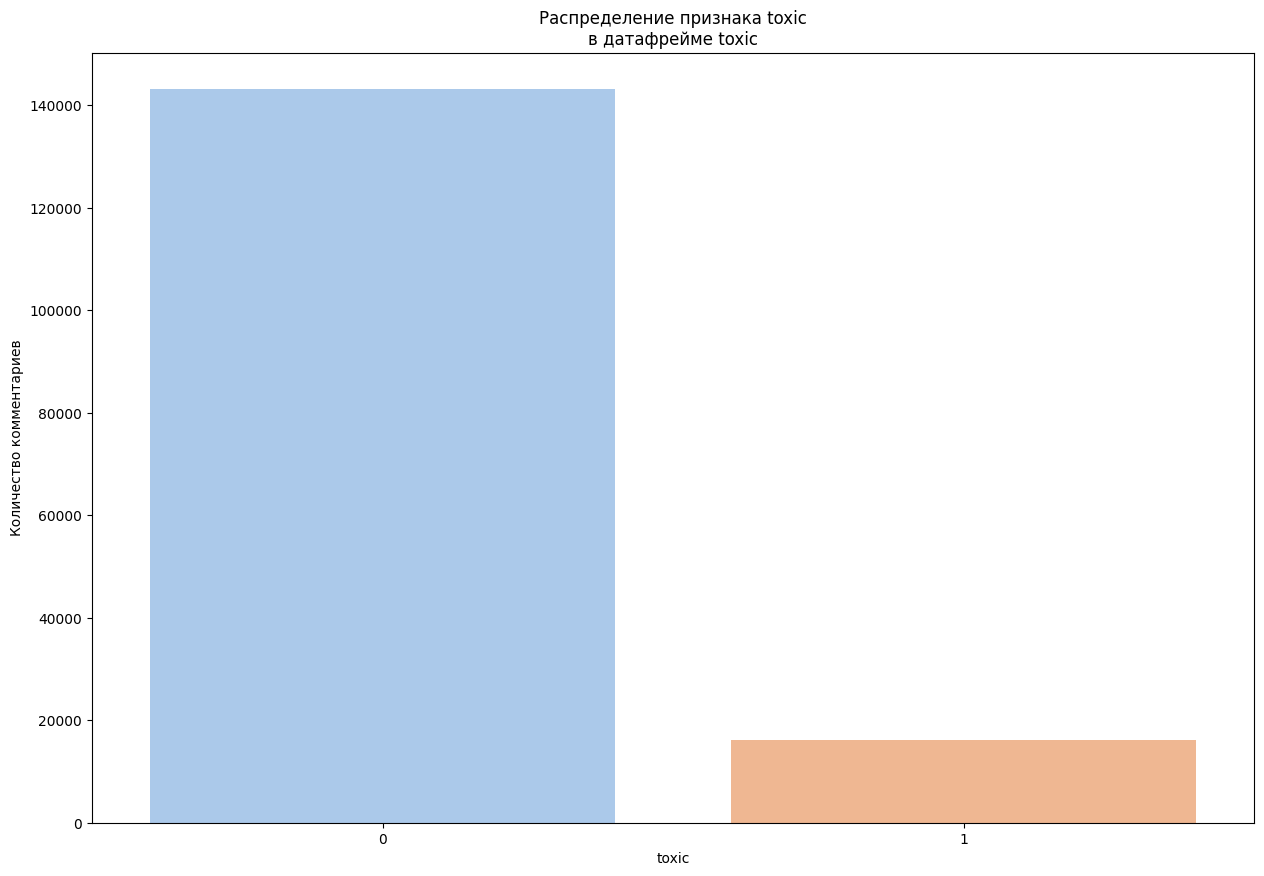

In [9]:
cat_feat_analysis(toxic, 'toxic', 'toxic')

Действительно наблюдается дисбаланс классов - негативных комментариев гораздо меньше. Обязательно учтём это при обучении моделей

Сделаем очистку текста - приведём все слова к нижнему регистру, а также удалим все ненужные символы, кроме слов и отдельных букв/буквенных сочетаний

In [10]:
toxic['text'] = toxic['text'].apply(lambda x: re.sub(r'[^a-z]', ' ', x.lower()))
toxic['text'] = toxic['text'].apply(lambda x: ' '.join(x.split()))
toxic.head()

,text,toxic
0,explanation why the edits made under my username hardcore metallica fan were reverted they weren t vandalisms just closure on some gas after i voted at new york dolls fac and please don t remove the template from the talk page since i m retired now,0
1,d aww he matches this background colour i m seemingly stuck with thanks talk january utc,0
2,hey man i m really not trying to edit war it s just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page he seems to care more about the formatting than the actual info,0
3,more i can t make any real suggestions on improvement i wondered if the section statistics should be later on or a subsection of types of accidents i think the references may need tidying so that they are all in the exact same format ie date format etc i can do that later on if no one else does first if you have any preferences for formatting style on references or want to do it yourself please let me know there appears to be a backlog on articles for review so i guess there may be a delay u...,0
4,you sir are my hero any chance you remember what page that s on,0


Очистка данных произведена успешно.


### Облака слов

Посмотрим на облака слов в зависимости от метки класса

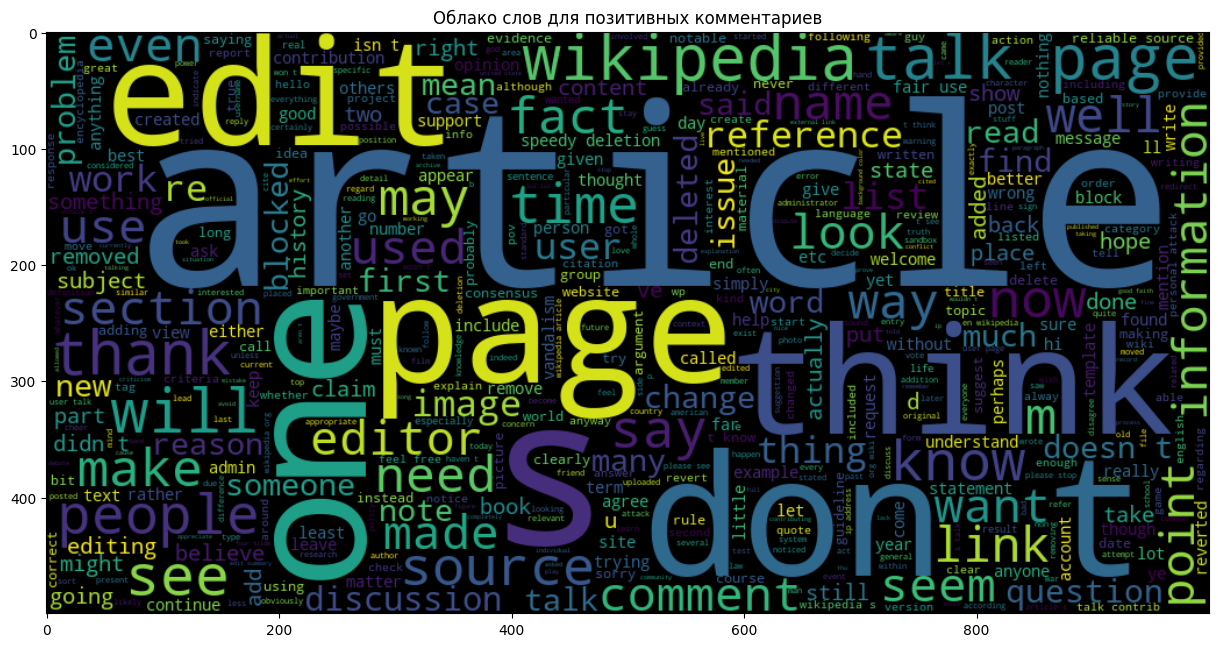

In [11]:
#позитивные|нейтральные комментарии
text_pos = ' '.join(toxic[toxic['toxic'] == 0]['text'].values)
WC = WordCloud(width=1000, height=500, max_words=500, min_font_size=5)
cloud = WC.generate(text_pos)
plt.imshow(cloud, interpolation='bilinear')
plt.title('Облако слов для позитивных комментариев')
plt.show()

Негативно окрашенные слова практически отсутствуют, в основном видим слова нейтральной или позитивной окраски

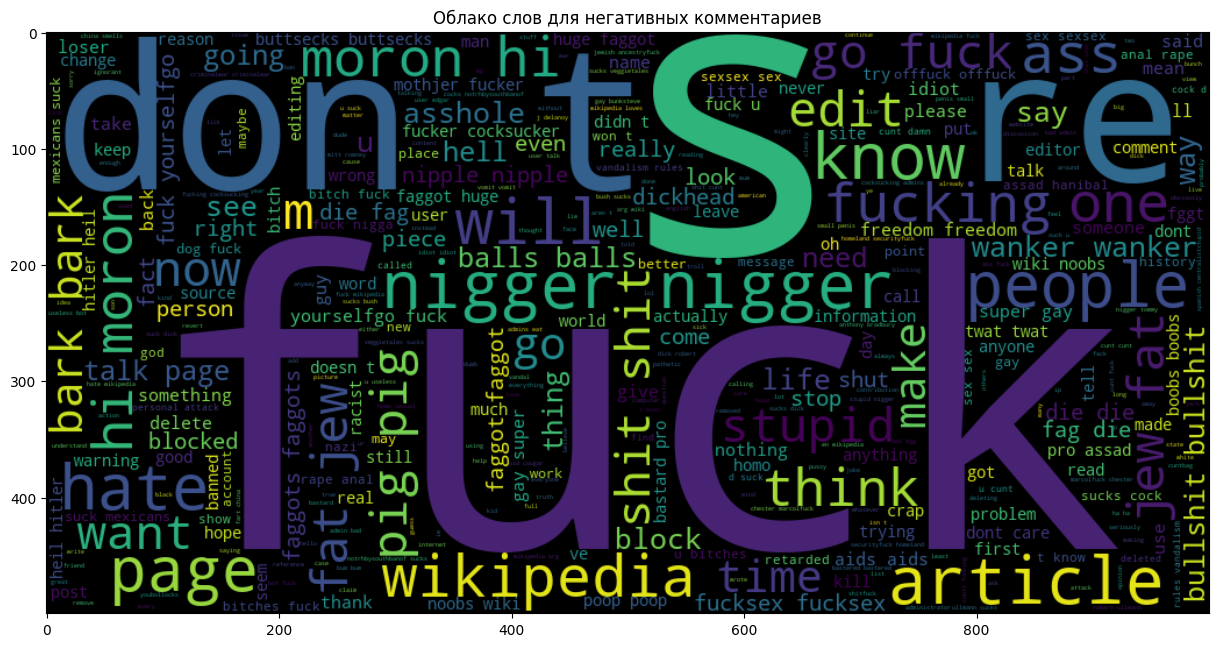

In [12]:
#негативные комментарии
text_neg = ' '.join(toxic[toxic['toxic'] == 1]['text'].values)
WC = WordCloud(width=1000, height=500, max_words=500, min_font_size=5)
cloud = WC.generate(text_neg)
plt.imshow(cloud, interpolation='bilinear')
plt.title('Облако слов для негативных комментариев')
plt.show()

Комментарии излишни - негативная окраска сообщений класса 1 явственно видна

### Лемматизация

Создадим класс для лемматизации

In [13]:
disabled_pipes = ['parser', 'ner']
nlp = spacy.load('en_core_web_sm', disable=disabled_pipes)

Создадим функцию для лемматизации одного текста

In [14]:
def lemmatize_text(text):
    
    #получаем объект doc,
    #затем получаем леммы, удаляем токены-пробелы, склеиваем токены обратно в строку
    doc = nlp(text)  
    return ' '.join([token.lemma_ for token in doc if not token.is_space])

Лемматизируем наши тексты

In [15]:
tqdm.pandas()
toxic['lemmas'] = toxic['text'].progress_apply(lemmatize_text)
toxic.head()

  0%|          | 0/159292 [00:00<?, ?it/s]

,text,toxic,lemmas
0,explanation why the edits made under my username hardcore metallica fan were reverted they weren t vandalisms just closure on some gas after i voted at new york dolls fac and please don t remove the template from the talk page since i m retired now,0,explanation why the edit make under my username hardcore metallica fan be revert they weren t vandalism just closure on some gas after I vote at new york dolls fac and please don t remove the template from the talk page since I m retire now
1,d aww he matches this background colour i m seemingly stuck with thanks talk january utc,0,d aww he match this background colour I m seemingly stick with thank talk january utc
2,hey man i m really not trying to edit war it s just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page he seems to care more about the formatting than the actual info,0,hey man I m really not try to edit war it s just that this guy be constantly remove relevant information and talk to I through edit instead of my talk page he seem to care more about the formatting than the actual info
3,more i can t make any real suggestions on improvement i wondered if the section statistics should be later on or a subsection of types of accidents i think the references may need tidying so that they are all in the exact same format ie date format etc i can do that later on if no one else does first if you have any preferences for formatting style on references or want to do it yourself please let me know there appears to be a backlog on articles for review so i guess there may be a delay u...,0,more I can t make any real suggestion on improvement I wonder if the section statistic should be later on or a subsection of type of accident I think the reference may need tidy so that they be all in the exact same format ie date format etc I can do that later on if no one else do first if you have any preference for formatting style on reference or want to do it yourself please let I know there appear to be a backlog on article for review so I guess there may be a delay until a reviewer tu...
4,you sir are my hero any chance you remember what page that s on,0,you sir be my hero any chance you remember what page that s on


Лемматизация произведена успешно

Таким образом, в данном разделе был проведён исследовательский анализ данных:
* подтверждён дисбаланс классов;
* визуальный анализ облак слов для каждого класса подтвердил значительные различия в лексике;
* проведена лемматизация текстов

## Обучение моделей, получение предсказаний

Перед векторизацией и обучением моделей разделим данные на выборки - тренировочную, валидационную и тестовую в соотношении 8:1:1; учтём также, что у нас дисбаланс классов

В качестве метрики заказчиком была выбрана `f1`.

In [16]:
X_train, X_val, y_train, y_val = train_test_split(toxic['lemmas'],
                                                  toxic['toxic'],
                                                  stratify=toxic['toxic'],
                                                  test_size=0.2,
                                                  random_state=123)

X_valid, X_test, y_valid, y_test = train_test_split(X_val,
                                                    y_val,
                                                    stratify=y_val,
                                                    test_size=0.5,
                                                    random_state=123)

X_train.shape, X_valid.shape, X_test.shape, y_train.shape, y_valid.shape, y_test.shape

((127433,), (15929,), (15930,), (127433,), (15929,), (15930,))

Разбиение на выборки произведено корректно. Проверим также корректность стратификации

In [17]:
y_train.value_counts(normalize=True), y_valid.value_counts(normalize=True), y_test.value_counts(normalize=True)

(0    0.898386
 1    0.101614
 Name: toxic, dtype: float64,
 0    0.898424
 1    0.101576
 Name: toxic, dtype: float64,
 0    0.898368
 1    0.101632
 Name: toxic, dtype: float64)

Баланс классов сохранён. Можно переходить к векторизации и обучению моделей. 


Будем исследовать различные векторизаторы для модели логистической регрессии с перебором основных гиперпараметров для последней - `C`, `penalty`, `solver`.

Оптимизацию гиперпараметров будем проводить с помощью `optuna`. Для каждой модели индивидуально подберём количество итераций оптимизации на основании различной скорости обучения и выхода на плато качества предсказаний на валидационной выборке. Качество моделей определим по метрике `f1` на валидационных данных. Лучшая модель будет использована для получения предсказаний на тестовых данных - успешным считается значение метрики `f1>=0.75`.

In [18]:
#создадим списки с названиями векторизаторов, метриками на валидационных данных
#и затраченным на все операции временем
vect_list = []
metrics_list = []
time_list = []

### CountVectorizer

Для объекта `CountVectorizer` в пайплайне переберём основные гиперпараметры - `ngram_range`, `min_df`, `max_df`, `max_features`. Проводилось 30 итераций оптимизации как оптимальное значение в контексте затраченного времени и качества модели

In [19]:
def objective_count(trial):
    
    # гиперпараметры CountVectorizer
    ngram_max = trial.suggest_int('ngram_max', 1, 2)
    min_df = trial.suggest_int('min_df', 1, 3)
    max_df = trial.suggest_float('max_df', 0.9, 1.0)
    max_features = trial.suggest_categorical('max_features', [None, 5000, 10000])

    # гиперпараметры LogisticRegression
    C = trial.suggest_float('C', 1e-3, 10, log=True)
    penalty = trial.suggest_categorical('penalty', ['l2', None])
    solver = trial.suggest_categorical('solver', ['saga', 'lbfgs'])

    #создаём пайплайн
    count = Pipeline([
        ('count', CountVectorizer(
            ngram_range=(1, ngram_max),
            min_df=min_df,
            max_df=max_df,
            max_features=max_features,
            stop_words=stopwords.words('english')  
        )),
        ('logreg', LogisticRegression(
            C=C, 
            penalty=penalty, 
            solver=solver,
            max_iter=1000,
            class_weight='balanced',
            random_state=123))
    ])

    count.fit(X_train, y_train)
    y_pred_count = count.predict(X_valid)
    
    return (f1_score(y_valid, y_pred_count))

In [20]:
# запускаем таймер
start = time.time()
        
# запускаем оптимизацию    
study_count = optuna.create_study(direction='maximize')
study_count.optimize(objective_count, n_trials=30)

# считаем, сколько секунд прошло с начала запуска
time_list.append(time.time() - start)

#проверяем работу модели на валидационной выборке
print('Гиперпараметры лучшей модели:', study_count.best_params)
print('Метрика лучшей модели на валидационной выборке:', study_count.best_value)

vect_list.append('CountVectorizer')
metrics_list.append(study_count.best_value)

[I 2025-09-22 17:21:56,773] A new study created in memory with name: no-name-a118b4df-b583-4177-b9d1-90adc0900889
[I 2025-09-22 17:22:18,055] Trial 0 finished with value: 0.698972873321043 and parameters: {'ngram_max': 1, 'min_df': 2, 'max_df': 0.9790344557122089, 'max_features': 10000, 'C': 0.0028647204046901146, 'penalty': None, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.698972873321043.
[I 2025-09-22 17:25:16,421] Trial 1 finished with value: 0.5557105840143512 and parameters: {'ngram_max': 2, 'min_df': 2, 'max_df': 0.9968928633048486, 'max_features': None, 'C': 1.7375284591352416, 'penalty': None, 'solver': 'saga'}. Best is trial 0 with value: 0.698972873321043.
[I 2025-09-22 17:26:39,621] Trial 2 finished with value: 0.5448843590748726 and parameters: {'ngram_max': 2, 'min_df': 1, 'max_df': 0.9551247325899219, 'max_features': 5000, 'C': 0.0026978026575855654, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 0 with value: 0.698972873321043.
[I 2025-09-22 17:27:50,106] Trial

[I 2025-09-22 17:54:21,881] Trial 29 finished with value: 0.6979246733282091 and parameters: {'ngram_max': 1, 'min_df': 1, 'max_df': 0.9380488751753625, 'max_features': 5000, 'C': 0.0023357865560948462, 'penalty': None, 'solver': 'lbfgs'}. Best is trial 15 with value: 0.7877992784519514.


Гиперпараметры лучшей модели: {'ngram_max': 2, 'min_df': 1, 'max_df': 0.938384950567409, 'max_features': None, 'C': 0.008988514836479557, 'penalty': None, 'solver': 'lbfgs'}
Метрика лучшей модели на валидационной выборке: 0.7877992784519514


Использование мешка слов в качестве векторизатора позволило получить удовлетворяющее требованиям заказчика значение метрики на валидации 

### TfidfVectorizer

Для объекта `TfidfVectorizer` в пайплайне переберём те же основные гиперпараметры - `ngram_range`, `min_df`, `max_df`, `max_features`. Проводилось 30 итераций оптимизации как оптимальное значение в контексте затраченного времени и качества модели

In [21]:
def objective_tfidf(trial):
    
    # гиперпараметры TfidfVectorizer
    ngram_max = trial.suggest_int('ngram_max', 1, 2)
    min_df = trial.suggest_int('min_df', 1, 3)
    max_df = trial.suggest_float('max_df', 0.9, 1.0)
    max_features = trial.suggest_categorical('max_features', [None, 5000, 10000])

    # гиперпараметры LogisticRegression
    C = trial.suggest_float('C', 1e-3, 10, log=True)
    penalty = trial.suggest_categorical('penalty', ['l2', None])
    solver = trial.suggest_categorical('solver', ['saga', 'lbfgs'])

    #создаём пайплайн
    tfidf = Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, ngram_max),
            min_df=min_df,
            max_df=max_df,
            max_features=max_features,
            stop_words=stopwords.words('english')  
        )),
        ('logreg', LogisticRegression(
            C=C, 
            penalty=penalty, 
            solver=solver,
            max_iter=1000,
            class_weight='balanced',
            random_state=123))
    ])

    tfidf.fit(X_train, y_train)
    y_pred_tfidf = tfidf.predict(X_valid)
    
    return (f1_score(y_valid, y_pred_tfidf))

In [22]:
# запускаем таймер
start = time.time()
        
# запускаем оптимизацию    
study_tfidf = optuna.create_study(direction='maximize')
study_tfidf.optimize(objective_tfidf, n_trials=30)

# считаем, сколько секунд прошло с начала запуска
time_list.append(time.time() - start)

#проверяем работу модели на валидационной выборке
print('Гиперпараметры лучшей модели:', study_tfidf.best_params)
print('Метрика лучшей модели на валидационной выборке:', study_tfidf.best_value)

vect_list.append('TfidfVectorizer')
metrics_list.append(study_tfidf.best_value)

[I 2025-09-22 17:54:21,920] A new study created in memory with name: no-name-552b9eba-ffa0-4c47-9c5c-e56c3f62629b
[I 2025-09-22 17:54:29,655] Trial 0 finished with value: 0.7693225902715607 and parameters: {'ngram_max': 1, 'min_df': 1, 'max_df': 0.9008857564074287, 'max_features': None, 'C': 1.6191125492354406, 'penalty': None, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.7693225902715607.
[I 2025-09-22 17:54:46,946] Trial 1 finished with value: 0.6850326611758023 and parameters: {'ngram_max': 2, 'min_df': 2, 'max_df': 0.9374332960119071, 'max_features': 5000, 'C': 0.0017544458644536568, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 0 with value: 0.7693225902715607.
[I 2025-09-22 17:55:57,177] Trial 2 finished with value: 0.6989450906140113 and parameters: {'ngram_max': 1, 'min_df': 3, 'max_df': 0.9673860671644172, 'max_features': 10000, 'C': 1.599596649193403, 'penalty': None, 'solver': 'saga'}. Best is trial 0 with value: 0.7693225902715607.
[I 2025-09-22 17:56:19,776] Trial

[I 2025-09-22 18:17:03,775] Trial 29 finished with value: 0.7953573610262675 and parameters: {'ngram_max': 2, 'min_df': 1, 'max_df': 0.9565122331079373, 'max_features': None, 'C': 0.0012161972066443113, 'penalty': None, 'solver': 'lbfgs'}. Best is trial 14 with value: 0.7953573610262675.


Гиперпараметры лучшей модели: {'ngram_max': 2, 'min_df': 1, 'max_df': 0.9440387585760778, 'max_features': None, 'C': 0.008900360505563538, 'penalty': None, 'solver': 'lbfgs'}
Метрика лучшей модели на валидационной выборке: 0.7953573610262675


Использование `TfidfVectorizer` привело к ещё более высокому значению метрики на валидации, удовлетворяющему требованиям заказчика

### Word2vec

Загружаем предобученный `Word2vec` - модель `glove-twitter-200`, обученную на 27 млрд твитов, генерирующую 200 эмбеддингов для каждого текста

In [23]:
w2v = gensim_api.load('glove-twitter-200')

Создадим функцию, возвращающую векторное представление для каждого текста

In [24]:
def get_mean_vector(tokens, model):
    #tokens - токены
    #model - модель
    
    #находим векторное представление для каждого слова, если оно есть в словаре модели
    vectors = [model[w] for w in tokens if w in model]
    
    #возвращаем усреднённый вектор для каждого текста,
    #если ни одного слова из текста нет в модели - возвращаем вектор из нулей
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)

Применим функцию для каждого текста на тренировочной и валидационной выборке

In [25]:
X_train_w2v = np.vstack(X_train.apply(lambda x: get_mean_vector(x, w2v)))
X_valid_w2v = np.vstack(X_valid.apply(lambda x: get_mean_vector(x, w2v)))

Проверим корректность векторизации выборок

In [26]:
X_train_w2v.shape, X_valid_w2v.shape

((127433, 200), (15929, 200))

Векторизация произведена успешно, можно переходить к обучению моделей

In [27]:
def objective_w2v(trial):
    
    # гиперпараметры LogisticRegression
    C = trial.suggest_float('C', 1e-3, 10, log=True)
    penalty = trial.suggest_categorical('penalty', ['l2', None])
    solver = trial.suggest_categorical('solver', ['saga', 'lbfgs'])

    #создаём пайплайн
    w2v_pipe = Pipeline([
        ('logreg', LogisticRegression(
            C=C, 
            penalty=penalty, 
            solver=solver,
            max_iter=1000,
            class_weight='balanced',
            random_state=123))
    ])

    w2v_pipe.fit(X_train_w2v, y_train)
    y_pred_w2v = w2v_pipe.predict(X_valid_w2v)
    
    return (f1_score(y_valid, y_pred_w2v))

In [28]:
# запускаем таймер
start = time.time()
        
# запускаем оптимизацию    
study_w2v = optuna.create_study(direction='maximize')
study_w2v.optimize(objective_w2v, n_trials=10)

# считаем, сколько секунд прошло с начала запуска
time_list.append(time.time() - start)

#проверяем работу модели на валидационной выборке
print('Гиперпараметры лучшей модели:', study_w2v.best_params)
print('Метрика лучшей модели на валидационной выборке:', study_w2v.best_value)

vect_list.append('Word2vec')
metrics_list.append(study_w2v.best_value)

[I 2025-09-22 18:20:34,806] A new study created in memory with name: no-name-c1139cea-5a15-42c4-b838-4d96f888dbf1
[I 2025-09-22 18:22:35,119] Trial 0 finished with value: 0.37327348066298344 and parameters: {'C': 0.006531232484489652, 'penalty': None, 'solver': 'saga'}. Best is trial 0 with value: 0.37327348066298344.
[I 2025-09-22 18:22:35,627] Trial 1 finished with value: 0.3702553485162181 and parameters: {'C': 0.14477127555479682, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.37327348066298344.
[I 2025-09-22 18:22:36,131] Trial 2 finished with value: 0.3702553485162181 and parameters: {'C': 0.1430919763031557, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.37327348066298344.
[I 2025-09-22 18:24:31,942] Trial 3 finished with value: 0.37327348066298344 and parameters: {'C': 0.7935982726490566, 'penalty': None, 'solver': 'saga'}. Best is trial 0 with value: 0.37327348066298344.
[I 2025-09-22 18:26:25,588] Trial 4 finished with value: 0.37327348

Гиперпараметры лучшей модели: {'C': 0.006531232484489652, 'penalty': None, 'solver': 'saga'}
Метрика лучшей модели на валидационной выборке: 0.37327348066298344


Качество предобученного `Word2vec` оказалось приблизительно в 2 раза хуже, чем `Bag of Words` и `TfidfVectorizer`, обученных на нашем корпусе, если судить по метрике `f1`. Возможно, не очень удачно оказался подобран предобученный корпус (хотя он выбирался максимально похожим под условие задачи), возможно, предобученный корпус не содержал обсценной лексики, которой был богат наш класс негативных комментариев, и не смог уловить тонкости минорного класса. Кроме того, в отличие от двух предыдущих векторизаторов, для предобученного `Word2vec` мы не могли осуществить подбор гиперпараметров, что тоже не могло не сказаться негативно на качестве классификации

### toxic-bert

Для анализа наших данных с помощью `BERT` возьмём модель `unitary/toxic-bert`, которая по типу лексики корпуса должна быть близка к нашим комментариям

Создадим случайную подвыборку из 5000 записей

In [29]:
toxic_bert = toxic[['text', 'toxic']].sample(n=5000, random_state=123)
toxic_bert.head()

,text,toxic
86912,it s very racist as well but then schwarzenegger never made a good movie,0
130370,let me be clear no more mr nice guy your fellow ideological partisan who you often coordinate edits and reverts with reverted me here i restored it and he reverted me again here so far you re just backing your ideological comrade on this talk page but you stand at the ready with support y all are masters at gaming the whole website to play a propaganda game good faith i m a grown man and i ve observed your behavior long enough assumptions of good faith get replaced by reasoned and informed o...,0
143172,ok no one s edited this talk page in years so i m just going to change it t c,0
79735,i went ahead and posted it on there contribs,0
131398,hi i m also from northern ireland,0


In [30]:
toxic_bert.shape

(5000, 2)

In [31]:
toxic_bert['toxic'].value_counts(normalize=True)

0    0.8986
1    0.1014
Name: toxic, dtype: float64

Получили подвыборку из 5000  записей, при этом баланс классов практически совпадает с исходным.

Создадим объекты классов `AutoModel` и `AutoTokenizer` из `toxic-bert`, загрузим веса

In [32]:
model, tokenizer =  ppb.AutoModel, ppb.AutoTokenizer

In [33]:
model_bert = model.from_pretrained('unitary/toxic-bert')
tokenizer_bert = tokenizer.from_pretrained('unitary/toxic-bert') 

Получим токены

In [34]:
tokenized = toxic_bert['text'].apply((lambda x: tokenizer_bert.encode(x,
                                                                      add_special_tokens=True,
                                                                      truncation=True,
                                                                      max_length=512)))

Проведём padding

In [35]:
max_len = 0
for i in tokenized.values:
    if len(i) > max_len:
        max_len = len(i)

padded = np.array([i + [0] * (max_len - len(i)) for i in tokenized.values])

np.array(padded).shape

(5000, 512)

Получим также маски

In [36]:
attention_mask = np.where(padded != 0, 1, 0)
attention_mask.shape

(5000, 512)

Явно зададим типы данных для генерации эмбеддингов

In [37]:
padded = np.array(padded, dtype=np.int64)
attention_mask = np.array(attention_mask, dtype=np.int64)

На основе padded и масок выделим эмбеддинги

In [38]:
batch_size = 100
embeddings = []
for i in  tqdm(range(padded.shape[0] // batch_size)):
    batch = torch.LongTensor(padded[batch_size * i:batch_size * (i + 1)])
    attention_mask_batch = torch.LongTensor(attention_mask[batch_size * i:batch_size * (i + 1)])
    with torch.no_grad():
        batch_embeddings = model_bert(batch, attention_mask=attention_mask_batch)
    embeddings.append(batch_embeddings[0][:, 0 ,:].numpy())

  0%|          | 0/50 [00:00<?, ?it/s]

Наконец, получим признаки

In [39]:
features = np.concatenate(embeddings)
features.shape

(5000, 768)

Таким образом, получили 768 признаков для имеющихся 5000 отобранных записей. Можно переходить к обучению моделей.

Разделим данные на выборки с учётом дисбаланса классов

In [40]:
X_train_bert, X_val_bert, y_train_bert, y_val_bert = train_test_split(features,
                                                                      toxic_bert['toxic'],
                                                                      stratify=toxic_bert['toxic'],
                                                                      test_size=0.2,
                                                                      random_state=123)

X_valid_bert, X_test_bert, y_valid_bert, y_test_bert = train_test_split(X_val_bert,
                                                                        y_val_bert,
                                                                        stratify=y_val_bert,
                                                                        test_size=0.5,
                                                                        random_state=123)

X_train_bert.shape, X_valid_bert.shape, X_test_bert.shape, y_train_bert.shape, y_valid_bert.shape, y_test_bert.shape

((4000, 768), (500, 768), (500, 768), (4000,), (500,), (500,))

Разбиение на выборки произведено коркектно. Проверим также корректность стратификации

In [41]:
y_train_bert.value_counts(normalize=True), y_valid_bert.value_counts(normalize=True), y_test_bert.value_counts(normalize=True)

(0    0.8985
 1    0.1015
 Name: toxic, dtype: float64,
 0    0.898
 1    0.102
 Name: toxic, dtype: float64,
 0    0.9
 1    0.1
 Name: toxic, dtype: float64)

Стратификация сохранена, можно переходить к обучению моделей

In [42]:
def objective_bert(trial):

    # гиперпараметры LogisticRegression
    C = trial.suggest_float('C', 1e-3, 10, log=True)
    penalty = trial.suggest_categorical('penalty', ['l2', None])
    solver = trial.suggest_categorical('solver', ['saga', 'lbfgs'])

    #создаём пайплайн
    bert = Pipeline([
        ('logreg', LogisticRegression(
            C=C, 
            penalty=penalty, 
            solver=solver,
            max_iter=1000,
            class_weight='balanced',
            random_state=123))
    ])

    bert.fit(X_train_bert, y_train_bert)
    y_pred_bert = bert.predict(X_valid_bert)
    
    return (f1_score(y_valid_bert, y_pred_bert))

In [43]:
# запускаем таймер
start = time.time()
        
# запускаем оптимизацию    
study_bert = optuna.create_study(direction='maximize')
study_bert.optimize(objective_bert, n_trials=30)

# считаем, сколько секунд прошло с начала запуска
time_list.append(time.time() - start)

#проверяем работу модели на валидационной выборке
print('Гиперпараметры лучшей модели:', study_bert.best_params)
print('Метрика лучшей модели на валидационной выборке:', study_bert.best_value)

vect_list.append('DistilBERT')
metrics_list.append(study_bert.best_value)

[I 2025-09-22 19:10:42,894] A new study created in memory with name: no-name-d5d0a586-ef7f-4659-b946-0a6025c6fd7f
[I 2025-09-22 19:10:43,102] Trial 0 finished with value: 0.8909090909090909 and parameters: {'C': 0.09135615219478896, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.8909090909090909.
[I 2025-09-22 19:10:43,181] Trial 1 finished with value: 0.8771929824561403 and parameters: {'C': 0.01082157377608637, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.8909090909090909.
[I 2025-09-22 19:10:43,337] Trial 2 finished with value: 0.8932038834951457 and parameters: {'C': 0.004778189314930597, 'penalty': None, 'solver': 'lbfgs'}. Best is trial 2 with value: 0.8932038834951457.
[I 2025-09-22 19:10:43,498] Trial 3 finished with value: 0.8932038834951457 and parameters: {'C': 0.3371446360477496, 'penalty': None, 'solver': 'lbfgs'}. Best is trial 2 with value: 0.8932038834951457.
[I 2025-09-22 19:10:43,654] Trial 4 finished with value: 0.89320388349

Гиперпараметры лучшей модели: {'C': 1.642295432025205, 'penalty': 'l2', 'solver': 'saga'}
Метрика лучшей модели на валидационной выборке: 0.9245283018867925


Предобученный `toxic-bert` показал наилучшие результаты среди всех моделей (правда, не будем забывать, что на небольшой выборке данных). Вероятно, сказался удачный подбор предобученной модели, хорошо определяющей минорный негативный класс. К тому же, `BERT` - наиболее мощная из исследованных моделей, которая учитывает контекст

Наконец, посмотрим на общие результаты

In [44]:
metrics_valid = pd.DataFrame({
    'vectorizer': vect_list,
    'f1_score': np.array(metrics_list),
    'time': time_list
})
metrics_valid.sort_values(by='f1_score', ascending=False)

,vectorizer,f1_score,time
3,DistilBERT,0.924528,429.659528
1,TfidfVectorizer,0.795357,1361.857746
0,CountVectorizer,0.787799,1945.108823
2,Word2vec,0.373273,503.473886


Как мы уже отмечали выше, наилучшие результаты по метрике `f1` показал `toxic-bert`. Логистическая регрессия над `CountVectorizer` и `Tfidf` справились лучше всего, если рассматривать модели, применявшиеся на всём объёме данных. При этом предобученный `Word2Vec` показал себя гораздо хуже остальных моделей

Для получения предсказаний на тестовых данных будем использовать наилучшую модель `Tfidf` - эта модель оказалась наиболее успешной на валидации

### Получение предсказаний на тестовых данных

Обучим модель `Tfidf` на лучших гиперпараметрах, получим предсказания на тренировочных, валидационных и тестовых данных

In [47]:
print(f'Лучшие параметры для логистической регрессии над Tfidf:{study_tfidf.best_params}')

Лучшие параметры для логистической регрессии над Tfidf:{'ngram_max': 2, 'min_df': 1, 'max_df': 0.9440387585760778, 'max_features': None, 'C': 0.008900360505563538, 'penalty': None, 'solver': 'lbfgs'}


In [48]:
best_params = study_tfidf.best_params

best_clf = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, best_params['ngram_max']),
        min_df=best_params['min_df'],
        max_df=best_params['max_df'],
        max_features=best_params['max_features'],
        stop_words=stopwords.words('english')  
    )),
    ('logreg', LogisticRegression(
        C=best_params['C'], 
        penalty=best_params['penalty'], 
        solver=best_params['solver'],
        max_iter=1000,
        class_weight='balanced',
        random_state=123))
])

best_clf.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9440387585760778, ngram_range=(1, 2),
                                 stop_words=['a', 'about', 'above', 'after',
                                             'again', 'against', 'ain', 'all',
                                             'am', 'an', 'and', 'any', 'are',
                                             'aren', "aren't", 'as', 'at', 'be',
                                             'because', 'been', 'before',
                                             'being', 'below', 'between',
                                             'both', 'but', 'by', 'can',
                                             'couldn', "couldn't", ...])),
                ('logreg',
                 LogisticRegression(C=0.008900360505563538,
                                    class_weight='balanced', max_iter=1000,
                                    penalty=None, random_state=123))])

In [49]:
y_pred_train = best_clf.predict(X_train)
y_pred_valid = best_clf.predict(X_valid)
y_pred_test = best_clf.predict(X_test)

f1_train = f1_score(y_train, y_pred_train)
f1_valid = f1_score(y_valid, y_pred_valid)
f1_test = f1_score(y_test, y_pred_test)

print(f"f1: train - {f1_train:.4f}, valid - {f1_valid:.4f}, test - {f1_test:.4f}")

f1: train - 0.9715, valid - 0.7954, test - 0.7872


Получили удовлетворяющие заказчика значения метрики `f1` как на валидационных данных, так и на тестовых. При этом нельзя не отметить, что качество предсказаний ощутимо падает на валидации и тесте по сравнению с тренировочными данными. Возможно, дело в переобучении - на огромном количестве признаков, сгенерированных `Tfidf`, модель просто могла подогнаться под тренировочные данные.

Посмотрим на `confusion_matrix` для каждой выборки

In [50]:
cm_train = confusion_matrix(y_train, y_pred_train)
cm_valid = confusion_matrix(y_valid, y_pred_valid)
cm_test = confusion_matrix(y_test, y_pred_test)

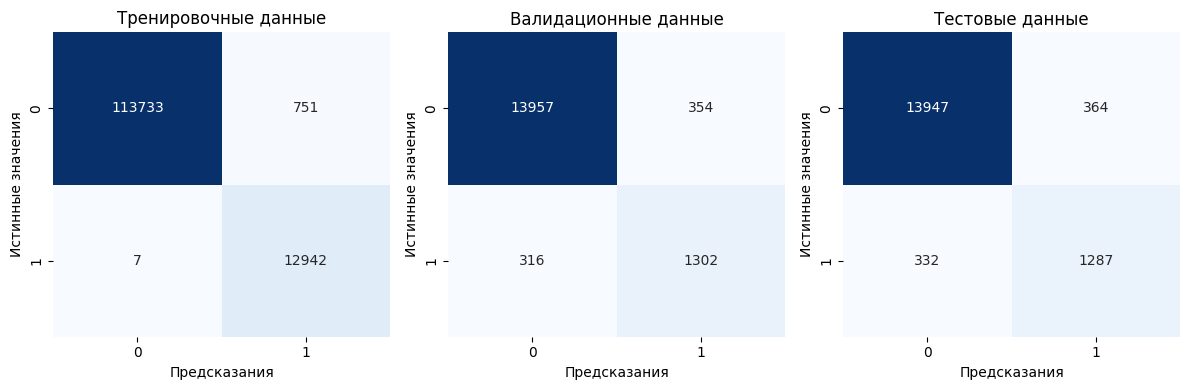

In [51]:
cms = [cm_train, cm_valid, cm_test]
titles = ['Тренировочные данные', 'Валидационные данные', 'Тестовые данные']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(title)
    ax.set_xlabel('Предсказания')
    ax.set_ylabel('Истинные значения')

plt.tight_layout()
plt.show()

Из сравнения `confusion_matrix` для тренировочных данных, а также валидационных и тестовых явно видно, что модель на самом деле не идеально научилась определять негативные комментарии и ошибается примерно в каждом пятом таком сообщении, классифицируя его как позитивное. На это, вероятно, повлиял дисбаланс классов, с которым не идеально справилась даже стратификация при разбиении исходных данных на выборки, а также инициализации логистической регрессии. Вероятно, нужно более глубоко бороться с малой долей негативных комментариев - например, собрать больше данных либо использовать `SMOTE`/oversampling

Таким образом, в данном разделе мы исследовали различные векторизаторы - `CountVectorizer`, `TfidfVectorizer`, а также предобученные `Word2vec` и `toxic-bert` для модели логистической регрессии с перебором основных гиперпараметров для последней - `C`, `penalty`, `solver`. Для первых двух векторизаторов в пайплайне также анализировали основные гиперпараметры - `ngram_range`, `min_df`, `max_df`, `max_features`. 

Оптимизацию гиперпараметров проводили с помощью `optuna`. Для каждой модели индивидуально подобрали количество итераций оптимизации на основании различной скорости обучения и выхода на плато качества предсказаний на валидационной выборке. Качество моделей определяли по метрике `f1` на валидационных данных.

В результате анализа было установлено, что логистическая регрессия над `CountVectorizer` и `Tfidf` показали наилучшие результаты на валидации среди моделей, исследовавшихся на всём корпусе данных. При этом предобученный `Word2Vec` показал себя гораздо хуже - вероятно, сказалось использование предобученной модели и недостаточно хорошая идентификация минорного класса, невозможность оптимизации гиперпараметров, отстутствие учёта контекста моделью.
При этом наилучший реультат по метрике `f1` показал предобученный `toxic-bert` на небольшой (3%) части данных. Вероятные причины - удачно подобранная предобученная модель, наиболее мощный алгоритм, учитывающий контекст данных

Для получения предсказаний на тестовых данных использовали наилучшую модель - `Tfidf`.

Для модели `Tfidf` с наилучшими гиперпараметрами получили удовлетворяющие заказчика значения метрики `f1` как на валидационных данных, так и на тестовых. При этом было установлено, что даже наилучшая модель на самом деле не идеально научилась определять негативные комментарии и ошибается примерно в каждом пятом таком сообщении. На это, вероятно, повлиял дисбаланс классов, и для улучшения результатов модели можно воспользоваться различными техниками борьбы с этим явлением - например, собрать больше негативных комментариев либо использовать `SMOTE`/oversampling. Либо же, если нам важнее определять точнее и удалять именно негативные комментарии, можно скорректировать порог классификации

## Итоговые выводы

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 


**Цель исследования:**

Обучить модель классифицировать комментарии на позитивные и негативные. В распоряжении - набор данных с разметкой о токсичности правок.

**Критерии, которые важны заказчику:**
* Построить модель со значением метрики качества `f1` не меньше 0.75.

**Ход исследования:**

1. *загрузка данных:*

В данном разделе были импортированы необходимые библиотеки, настроено отображение данных, загружен датасет

2. *предобработка данных:*

В данном разделе была проведена базовая предобработка данных:
   * удалён неинформативный признак;
   * установлено отсутствие дубликатов и пропущенных значений;
   * отмечен дисбаланс классов таргета

3. *исследовательский анализ данных:*

В данном разделе был проведён исследовательский анализ данных:
* подтверждён дисбаланс классов;
* визуальный анализ облак слов для каждого класса подтвердил значительные различия в лексике;
* проведена лемматизация текстов


4. *обучение моделей, получение предсказаний:*

В данном разделе мы исследовали различные векторизаторы - `CountVectorizer`, `TfidfVectorizer`, а также предобученные `Word2vec` и `toxic-bert` для модели логистической регрессии с перебором основных гиперпараметров для последней - `C`, `penalty`, `solver`. Для первых двух векторизаторов в пайплайне также анализировали основные гиперпараметры - `ngram_range`, `min_df`, `max_df`, `max_features`. 

Оптимизацию гиперпараметров проводили с помощью `optuna`. Для каждой модели индивидуально подобрали количество итераций оптимизации на основании различной скорости обучения и выхода на плато качества предсказаний на валидационной выборке. Качество моделей определяли по метрике `f1` на валидационных данных.

В результате анализа было установлено, что логистическая регрессия над `CountVectorizer` и `Tfidf` показали наилучшие результаты на валидации среди моделей, исследовавшихся на всём корпусе данных. При этом предобученный `Word2Vec` показал себя гораздо хуже - вероятно, сказалось использование предобученной модели и недостаточно хорошая идентификация минорного класса, невозможность оптимизации гиперпараметров, отстутствие учёта контекста моделью.
При этом наилучший реультат по метрике `f1` показал предобученный `toxic-bert` на небольшой (3%) части данных. Вероятные причины - удачно подобранная предобученная модель, наиболее мощный алгоритм, учитывающий контекст данных

Для получения предсказаний на тестовых данных использовали наилучшую модель - `Tfidf`.

Для модели `Tfidf` с наилучшими гиперпараметрами получили удовлетворяющие заказчика значения метрики `f1` как на валидационных данных, так и на тестовых. При этом было установлено, что даже наилучшая модель на самом деле не идеально научилась определять негативные комментарии и ошибается примерно в каждом пятом таком сообщении. На это, вероятно, повлиял дисбаланс классов, и для улучшения результатов модели можно воспользоваться различными техниками борьбы с этим явлением - например, собрать больше негативных комментариев либо использовать `SMOTE`/oversampling. Либо же, если нам важнее определять точнее и удалять именно негативные комментарии, можно скорректировать порог классификации